# CallMeMaybe — Operator Efficiency Analysis

## Table of Contents

## 1. Introduction and Business Context
## 2. Study Objectives
## 3. Data Loading and Initial Inspection
## 4. Data Preprocessing
## 5. Exploratory Data Analysis
## 6. Definition of Operator Inefficiency Criteria
## 7. Identification of Inefficient Operators
## 8. Statistical Hypothesis Testing
## 9. Business Interpretation
## 10. Conclusions and Recommendations

# 1. Introduction and Business Context

CallMeMaybe is a virtual telephony service used by organizations that manage large volumes of incoming and outgoing calls through multiple operators.

The company is developing an analytical framework to help supervisors identify operators who may require additional attention. Potential signs of operational inefficiency include elevated missed incoming-call rates, long waiting times for incoming calls, and unusually low outgoing activity when outbound work is part of the operator's responsibilities.

However, operator roles and workloads may vary considerably. For this reason, performance should not be evaluated using a single universal metric or arbitrary threshold. The analysis therefore uses data-driven criteria and multiple performance indicators to identify unusual operator behavior while accounting for differences in activity profiles.

The goal of this project is to analyze operator performance, define measurable inefficiency criteria, identify operators who show potential performance issues, and translate the findings into practical recommendations for supervisors.

# 2. Study Objectives

The main objectives of this analysis are to:

- Assess the structure and quality of the available telecom data.
- Explore call activity patterns across operators and client accounts.
- Develop operator-level performance metrics for incoming and outgoing activity.
- Define transparent, data-driven thresholds for identifying potentially inefficient behavior.
- Identify operators who meet one or more inefficiency criteria and distinguish high-priority cases.
- Assess whether differences in key incoming-call performance metrics between classified groups are statistically significant.
- Translate the analytical findings into practical recommendations for monitoring, workload review, and operator support.

In [39]:
# Import the libraries required for data analysis and visualization

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

# 3. Data Loading and Initial Inspection

The analysis uses two datasets:

- `telecom_dataset_new.csv`: contains call activity records, including call direction, operator identifiers, missed-call status, call counts, and call duration metrics.
- `telecom_clients.csv`: contains client account information, including tariff plans and registration dates.

The datasets are loaded and inspected to understand their structure, dimensions, variable types, and overall data quality before preprocessing and analysis.

In [40]:
# Load the datasets
telecom =pd.read_csv('../data/telecom_dataset_new.csv')
clients = pd.read_csv('../data/telecom_clients.csv')

In [41]:
# Display datasets dimensions
print('Telecom dataset shape:', telecom.shape)
print('Clients dataset shape:', clients.shape)

# Preview the datasets
print('\nTelecom dataset:')
display(telecom.head())

print('\nClients dataset:')
display(clients.head())

Telecom dataset shape: (53902, 9)
Clients dataset shape: (732, 3)

Telecom dataset:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25



Clients dataset:


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


# 4. Data Quality and Preprocessing

Before performing the exploratory analysis, both datasets are assessed for data type issues, missing values, duplicated records, and inconsistent or implausible values.

Special attention is given to missing `operator_id` values and call-duration variables because these directly affect the construction of operator-level performance metrics.

The preprocessing stage includes:

- validating and converting data types;
- identifying and handling duplicated records;
- examining missing values and their distribution;
- reviewing categorical fields for unexpected values;
- checking call-duration consistency;
- creating derived variables required for the analysis;
- preparing a separate operator-level analytical dataset when operator attribution is required.

These steps are intended to preserve as much valid information as possible while ensuring that operator performance metrics are based on reliable and attributable records.

In [42]:
# Inspect dataset structure
print('Telecom dataset:')
telecom.info()

print('\nClients dataset:')
clients.info()

Telecom dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

Clients dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tari

In [43]:
# Check missing values 
print('Missing values in telecom dataset:')
print(telecom.isna().sum())

print('\nMissing values in clients dataset:')
print(clients.isna().sum())

Missing values in telecom dataset:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Missing values in clients dataset:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [44]:
# Check duplicated rows 
print('\nDuplicate rows:')
print('Duplicated rows in telecom dataset:', telecom.duplicated().sum())
print('Duplicated rows in clients dataset:', clients.duplicated().sum())


Duplicate rows:
Duplicated rows in telecom dataset: 4900
Duplicated rows in clients dataset: 0


### Initial Data Quality Findings

The initial inspection identified several data quality issues that require further investigation before preprocessing decisions are made:

- The telecom dataset contains **8,172 missing `operator_id` values**. Because operator attribution is essential for operator-level performance analysis, these records must be examined carefully before deciding how they should be handled.
- The `internal` column contains **117 missing values**.
- The telecom dataset contains **4,900 fully duplicated rows**, while the client dataset contains no duplicated records.
- The `date` and `date_start` columns are currently stored as object types and need to be converted to datetime format.

Rather than removing records immediately, each issue will be investigated individually to preserve potentially meaningful information and avoid introducing unnecessary bias into the analysis.

In [45]:
# Convert date columns to datetime format 

telecom['date'] = pd.to_datetime(telecom['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Convert identifier and boolean fields to appropriate nullable data types

telecom['operator_id'] = telecom['operator_id'].astype('Int64')
telecom['internal'] = telecom['internal'].astype('boolean')

# Verify the converted data types

print('Telecom date type:', telecom['date'].dtype)
print('Clients date_start type:', clients['date_start'].dtype)

print('Operator ID type:', telecom['operator_id'].dtype)
print('Internal type:', telecom['internal'].dtype)

Telecom date type: datetime64[ns, UTC+03:00]
Clients date_start type: datetime64[ns]
Operator ID type: Int64
Internal type: boolean


In [46]:
# Inspect records with missing operator IDs

missing_operator = telecom[telecom['operator_id'].isna()]

print('Rows with missing operator_id:', len(missing_operator))

# Compare call direction among records without operator identification

print('\nCall direction:')
print(missing_operator['direction'].value_counts(dropna = False))

# Compare missed-call status

print('\nMissed call status:')
print(missing_operator['is_missed_call'].value_counts(dropna = False))

# Compare internal/external call status

print('\nInternal call status:')
print(missing_operator['internal'].value_counts(dropna = False))

Rows with missing operator_id: 8172

Call direction:
direction
in     7972
out     200
Name: count, dtype: int64

Missed call status:
is_missed_call
True     8050
False     122
Name: count, dtype: int64

Internal call status:
internal
False    7760
True      355
<NA>       57
Name: count, dtype: Int64


In [47]:
# Inspect records with missing internal-call information

missing_internal = telecom[telecom['internal'].isna()]

print('Rows with missing internal values:', len(missing_internal))

print('\nCall direction:')
print(missing_internal['direction'].value_counts(dropna = False))

print('\nMissed call status:')
print(missing_internal['is_missed_call'].value_counts(dropna = False))

print('\nMissing operator IDs:')
print(missing_internal['operator_id'].isna().value_counts())

Rows with missing internal values: 117

Call direction:
direction
in     115
out      2
Name: count, dtype: int64

Missed call status:
is_missed_call
False    59
True     58
Name: count, dtype: int64

Missing operator IDs:
operator_id
False    60
True     57
Name: count, dtype: int64


In [48]:
# Inspect unique values in categorical variables

print('Direction values:')
print(telecom['direction'].value_counts(dropna = False))

print('\nInternal values:')
print(telecom['internal'].value_counts(dropna = False))

print('\nMissed-call values:')
print(telecom['is_missed_call'].value_counts(dropna = False))

print('\nTariff plans:')
print(clients['tariff_plan'].value_counts(dropna = False))

Direction values:
direction
out    31917
in     21985
Name: count, dtype: int64

Internal values:
internal
False    47621
True      6164
<NA>       117
Name: count, dtype: Int64

Missed-call values:
is_missed_call
False    30334
True     23568
Name: count, dtype: int64

Tariff plans:
tariff_plan
C    395
B    261
A     76
Name: count, dtype: int64


### Missing Values and Data Quality Decisions

The analysis of missing values revealed that missing `operator_id` values are highly concentrated among incoming and missed calls. Of the 8,172 records without an operator identifier, 7,972 correspond to incoming calls and 8,050 are marked as missed calls.

This pattern suggests that many of these calls were not handled or assigned to a specific operator. Therefore, these records cannot be reliably attributed to individual operator performance.

For this reason:

- Records without `operator_id` will be preserved for general call-level analysis when relevant.
- They will be excluded from operator-level efficiency calculations because no individual operator can be identified.
- Missing values in `internal` will not be imputed, since there is insufficient information to determine whether these calls were internal or external.
- Exact duplicated records will be removed to avoid double-counting call activity.

This approach preserves useful information while preventing unidentified calls from distorting operator-level performance metrics.

In [49]:
# Create a cleaned copy of the telecom dataset
telecom_clean = telecom.drop_duplicates().copy()

# Compare dataset size before and after removing duplicates
print('Rows before removing duplicates:', len(telecom))
print('Rows after removing duplicates:', len(telecom_clean))
print('Removed duplicated rows:', len(telecom) - len(telecom_clean))

Rows before removing duplicates: 53902
Rows after removing duplicates: 49002
Removed duplicated rows: 4900


In [50]:
# Create a dataset for operator-level analysis
# Calls without an operator ID cannot be attributed to a specific operator 

operator_data = telecom_clean.dropna(subset = ['operator_id']).copy()

# Convert operator IDs to integer after removing missing values
operator_data['operator_id'] = operator_data['operator_id'].astype(int)

print('Total cleaned call records:', len(telecom_clean))
print('Records available for operator analysis:', len(operator_data))
print('Unique operators:', operator_data['operator_id'].nunique())

Total cleaned call records: 49002
Records available for operator analysis: 41546
Unique operators: 1092


In [51]:
# Check call-duration variables for impossible or inconsistent values

print('Call duration summary:')
display(telecom_clean[['calls_count', 'call_duration', 'total_call_duration']].describe())

# Check for negative values
print('\nNegative call duration values:',
     (telecom_clean['call_duration'] < 0).sum())

print('Negative total call duration values:',
     (telecom_clean['total_call_duration'] < 0).sum())

# Check whether total duration is ever smaller than call duration
inconsistent_duration = telecom_clean[
    telecom_clean['total_call_duration'] < telecom_clean['call_duration']
]

print('Rows where total call_duration < call_duration:', len(inconsistent_duration))

Call duration summary:


,calls_count,call_duration,total_call_duration
count,49002.000000,49002.000000,49002.000000
mean,16.462777,866.282091,1156.558202
std,63.604098,3775.503352,4451.473661
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,46.000000
50%,4.000000,37.000000,208.000000
75%,12.000000,570.000000,901.000000
max,4817.000000,144395.000000,166155.000000



Negative call duration values: 0
Negative total call duration values: 0
Rows where total call_duration < call_duration: 0


### Call Duration Consistency and Waiting Time

The duration variables were checked for impossible or inconsistent values. No negative durations were found, and there are no records where `total_call_duration` is smaller than `call_duration`.

However, the distributions show substantial differences between typical and maximum values, suggesting the presence of potential outliers. These values will be examined during the exploratory analysis before defining operator inefficiency thresholds.

Waiting time will be derived as the difference between total call duration and actual conversation duration. Since each record may represent multiple calls, an average waiting time per call will also be calculated.

In [52]:
# Calculate total waiting time for the calls represented by each row

telecom_clean['waiting_time'] = (
    telecom_clean['total_call_duration'] - telecom_clean['call_duration']
)

operator_data['waiting_time'] = (
    operator_data['total_call_duration'] - operator_data['call_duration']
)

# Calculate average waiting time per call for each aggregated record

telecom_clean['avg_waiting_time'] = (
    telecom_clean['waiting_time'] / telecom_clean['calls_count']
)

operator_data['avg_waiting_time'] = (
    operator_data['waiting_time'] / operator_data['calls_count']
)

# Inspect the derived variables

display(
    operator_data[
        ['calls_count', 'call_duration', 'total_call_duration', 'waiting_time', 'avg_waiting_time']
    ].describe()
)

,calls_count,call_duration,total_call_duration,waiting_time,avg_waiting_time
count,41546.000000,41546.000000,41546.000000,41546.000000,41546.000000
mean,16.900424,1009.769172,1321.592813,311.823641,16.541111
std,59.749373,4064.106117,4785.978633,1175.373073,11.952638
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,67.000000,19.000000,8.476481
50%,4.000000,106.000000,288.000000,60.000000,14.666667
75%,13.000000,770.000000,1104.000000,219.000000,21.721995
max,4817.000000,144395.000000,166155.000000,46474.000000,451.203883


In [53]:
# Check the data range convered by the telecom dataset

print('First telecom date:', telecom_clean['date'].min())
print('Last telecom date:', telecom_clean['date'].max())

# Check the number of client accounts and operators

print('\nUnique client accounts:', telecom_clean['user_id'].nunique())
print('Unique identified operators:', operator_data['operator_id'].nunique())

First telecom date: 2019-08-02 00:00:00+03:00
Last telecom date: 2019-11-28 00:00:00+03:00

Unique client accounts: 307
Unique identified operators: 1092


# 5. Exploratory Data Analysis

The exploratory analysis examines overall call activity, including call direction, internal and external call behavior, missed calls, waiting times, operator workload, and potential outliers.

Because operator roles and activity levels may differ substantially, incoming and outgoing behavior will be analyzed separately where appropriate.

Each visualization is followed by a brief interpretation describing the operational or business relevance of the observed patterns.

Total calls by direction:
direction
out    608864
in     197845
Name: calls_count, dtype: int64


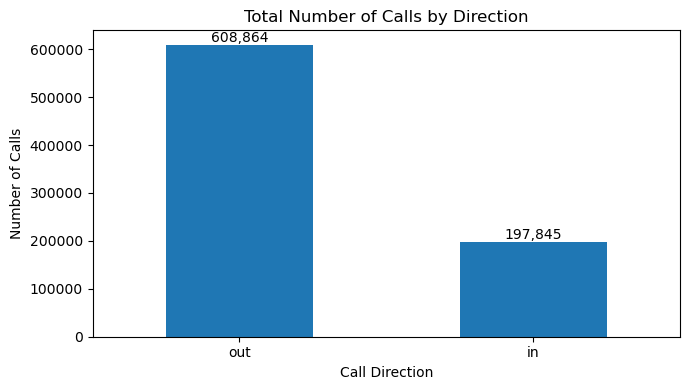

In [54]:
# Aggregate the total number of calls by direction

calls_by_direction = (
    telecom_clean
    .groupby('direction')['calls_count']
    .sum()
    .sort_values(ascending = False)
)

print('Total calls by direction:')
print(calls_by_direction)

# Plot incoming and outgoing call volume

ax = calls_by_direction.plot(
    kind = 'bar',
    figsize = (7, 4)
)

plt.title('Total Number of Calls by Direction')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation = 0)

# Add value labels

for container in ax.containers:
    ax.bar_label(container, fmt = '{:,.0f}')

plt.tight_layout()
plt.show()

### Interpretation — Call Direction

Outgoing calls account for approximately **75% of total call volume**, while incoming calls represent about **25%**, indicating that the overall dataset is strongly oriented toward outbound activity.

However, this aggregate pattern should not be interpreted as evidence that every operator performs primarily outbound work. Individual operator roles and workloads may differ considerably, so incoming and outgoing performance will be evaluated separately at the operator level.

Incoming-call performance remains particularly important because missed-call rates and waiting times are key service-quality indicators used later in the analysis.

Total calls by internal/external status:
internal
External    791829
Internal     14655
Name: calls_count, dtype: int64


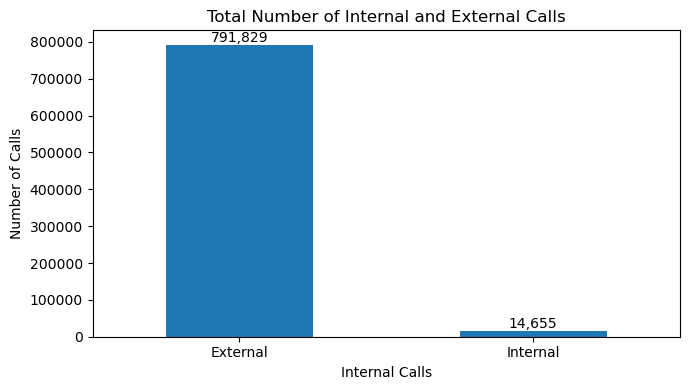

In [55]:
# Aggregate the total number of calls by internal/external status

calls_by_internal = (
    telecom_clean
    .dropna(subset = ['internal'])
    .groupby('internal')['calls_count']
    .sum()
)

# Replace boolean labels with descriptive categories

calls_by_internal.index = calls_by_internal.index.map({
    False : 'External',
    True : 'Internal'
})

print('Total calls by internal/external status:')
print(calls_by_internal)

# PLot the distribution

ax = calls_by_internal.plot(
    kind = 'bar',
    figsize = (7, 4)
)

plt.title('Total Number of Internal and External Calls')
plt.xlabel('Internal Calls')
plt.ylabel('Number of Calls')
plt.xticks(rotation = 0)

for container in ax.containers:
    ax.bar_label(container, fmt = '{:,.0f}')

plt.tight_layout()
plt.show()

### Interpretation — Internal and External Calls

External calls account for approximately **98% of total call volume**, while internal calls represent only about **2%** of observed activity.

This indicates that CallMeMaybe's overall call activity is overwhelmingly driven by interactions involving external contacts rather than internal communication.

Because external calls dominate the dataset, most operator workload and service-level patterns are likely to be influenced by external call activity. Nevertheless, the internal/external classification is treated as contextual information rather than a direct criterion for operator inefficiency.

The 117 records with unknown internal/external status are excluded only from this specific comparison and remain available for analyses that do not require this classification.

Total calls by missed-call status:
is_missed_call
Answered / Completed    430791
Missed                  375918
Name: calls_count, dtype: int64


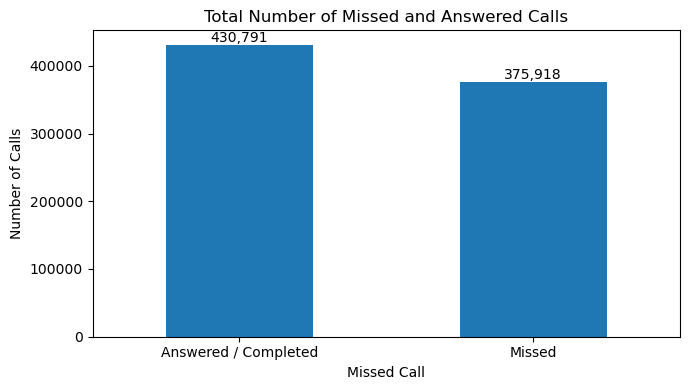

In [56]:
# Calculate the total number of missed and answered calls

calls_by_missed_status = (
    telecom_clean
    .groupby('is_missed_call')['calls_count']
    .sum()
)

# Replace boolean labels with descriptive categories

calls_by_missed_status.index = calls_by_missed_status.index.map({
    False : 'Answered / Completed',
    True : 'Missed'
})

print('Total calls by missed-call status:')
print(calls_by_missed_status)

# Plot the distribution

ax = calls_by_missed_status.plot(
    kind = 'bar',
    figsize = (7, 4)
)

plt.title('Total Number of Missed and Answered Calls')
plt.xlabel('Missed Call')
plt.ylabel('Number of Calls')
plt.xticks(rotation = 0)

for container in ax.containers:
    ax.bar_label(container, fmt = '{:,.0f}')

plt.tight_layout()
plt.show()

### Interpretation — Missed Calls

Approximately **46.6% of total call volume** is classified as missed, compared with **53.4%** classified as not missed.

This overall proportion should not be interpreted as an operator inefficiency rate because it combines incoming and outgoing activity. The operational meaning of a missed call differs by call direction, and the business definition of inefficiency specifically emphasizes **missed incoming calls**.

For this reason, the next stage isolates incoming activity and evaluates missed-call behavior separately before operator-level performance metrics are constructed.

Total incoming calls: 197845
Missed incoming calls 104323
Incoming missed-call rate: 52.73%


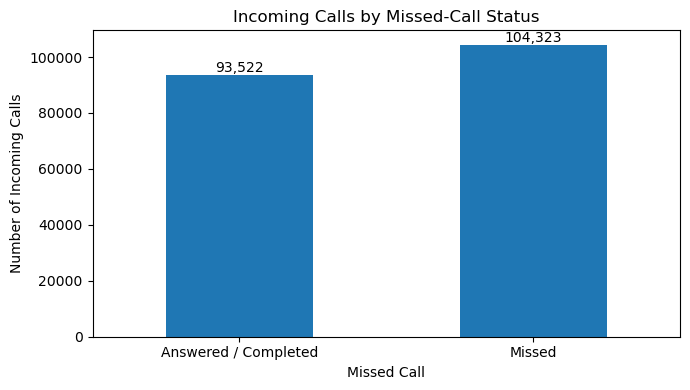

In [57]:

# Select incoming calls only
incoming_calls = telecom_clean[
    telecom_clean['direction'] == 'in'
].copy()

# Aggregate incoming calls by missed-call status
incoming_missed_status = (
    incoming_calls
    .groupby('is_missed_call')['calls_count']
    .sum()
)

# Calculate overall incoming missed-call rate
total_incoming_calls = incoming_missed_status.sum()
missed_incoming_calls = incoming_missed_status.get(True, 0)
incoming_missed_rate = missed_incoming_calls / total_incoming_calls

print('Total incoming calls:', total_incoming_calls)
print('Missed incoming calls', missed_incoming_calls)
print(f'Incoming missed-call rate: {incoming_missed_rate:.2%}')

# Use descriptive labels for the visualization
incoming_missed_plot = incoming_missed_status.copy()
incoming_missed_plot.index = incoming_missed_plot.index.map({
    False : 'Answered / Completed',
    True : 'Missed'
})

ax = incoming_missed_plot.plot(
    kind = 'bar',
    figsize = (7, 4)
)

plt.title('Incoming Calls by Missed-Call Status')
plt.xlabel('Missed Call')
plt.ylabel('Number of Incoming Calls')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt = '{:,.0f}')

plt.tight_layout()
plt.show()

### Interpretation — Incoming Missed Calls

Of the **197,845 incoming calls** recorded in the cleaned dataset, **104,323 were classified as missed**, corresponding to an overall incoming missed-call rate of approximately **52.73%**.

This indicates that missed incoming calls are an important service-level issue in the observed data. However, this rate should not be interpreted as an operator-level performance measure. As identified during preprocessing, missing `operator_id` values are heavily concentrated among incoming missed calls, meaning that many of these calls cannot be reliably attributed to a specific operator.

Therefore, the overall incoming missed-call rate is used here to describe the broader operational context. Operator efficiency will later be evaluated only with calls that can be attributed to identified operators, using operator-level missed-call rates and sufficient activity context.

Incoming-call waiting time summary:


count    12733.000000
mean        16.475682
std         13.561363
min          0.000000
25%          7.666667
50%         13.000000
75%         21.333333
max        261.000000
Name: avg_waiting_time, dtype: float64

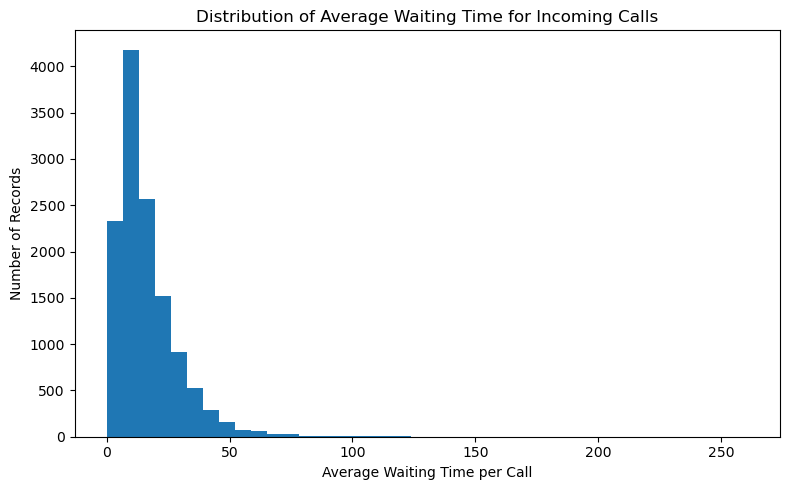

In [58]:
# Select incoming calls with identified operators
incoming_operator_calls = operator_data[
    operator_data['direction'] == 'in'
].copy()

# Display summary statistics for average waiting time per call
print('Incoming-call waiting time summary:')
display(
    incoming_operator_calls['avg_waiting_time']
    .describe()
)

# Plot the distribution of average waiting time per incoming call
plt.figure(figsize = (8, 5))

plt.hist(
    incoming_operator_calls['avg_waiting_time'],
    bins = 40
)

plt.title('Distribution of Average Waiting Time for Incoming Calls')
plt.xlabel('Average Waiting Time per Call')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

### Interpretation — Incoming Waiting Time

The distribution of average waiting time for incoming calls is strongly right-skewed. Most observations are concentrated at relatively low waiting times, while a small number of records show substantially longer waits.

The median waiting time is approximately **13 seconds**, while the 75th percentile is approximately **21.33 seconds**. The maximum observed value reaches **261 seconds**, confirming the presence of extreme observations in the upper tail of the distribution.

Because the distribution is asymmetric and influenced by outliers, the mean is not an ideal reference point for defining unusually long waiting times. Percentile-based thresholds are therefore more appropriate for this metric.

The 75th percentile will be evaluated later as a candidate cutoff when defining operator-level inefficiency criteria.

Outgoing calls per operator summary:


count      882.000000
mean       689.731293
std       3122.953946
min          1.000000
25%         11.000000
50%         90.000000
75%        597.250000
max      58977.000000
Name: calls_count, dtype: float64

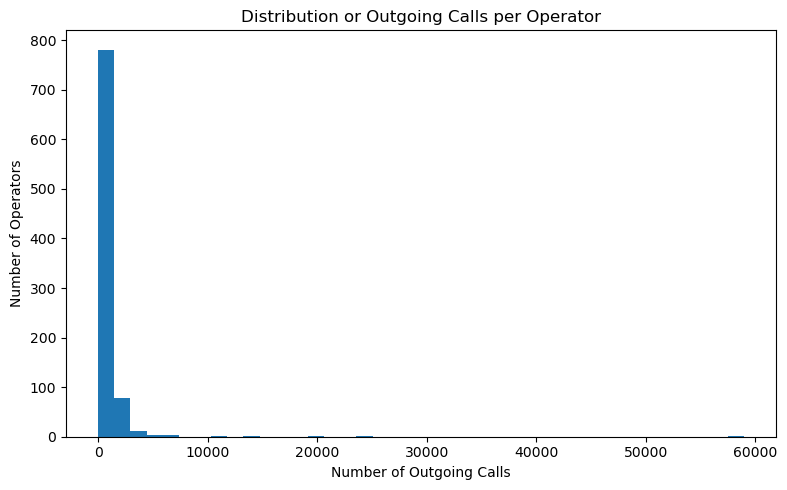

In [59]:
# Select outgoing calls with identified operators
outgoing_operator_calls = operator_data[
    operator_data['direction'] == 'out'
].copy()

# Aggregate the total number of outgoing calls by operator
outgoing_calls_by_operator = (
    outgoing_operator_calls
    .groupby('operator_id')['calls_count']
    .sum()
)

# Display summary statistics
print('Outgoing calls per operator summary:')
display(outgoing_calls_by_operator.describe())

# PLot the distribution
plt.figure(figsize = (8,5))

plt.hist(
    outgoing_calls_by_operator,
    bins = 40
)

plt.title('Distribution or Outgoing Calls per Operator')
plt.xlabel('Number of Outgoing Calls')
plt.ylabel('Number of Operators')

plt.tight_layout()
plt.show()

### Interpretation — Outgoing Call Activity

The distribution of outgoing calls per operator is highly right-skewed. Most operators generate relatively low or moderate outbound volumes, while a small number of operators account for extremely large numbers of outgoing calls.

The median is **90 outgoing calls per operator**, the 25th percentile is **11 calls**, and the maximum reaches **58,977 calls**, confirming substantial variation in operator activity and the presence of extreme high-volume cases.

Because of this strong skewness, the mean is not an appropriate reference point for identifying unusually low outbound activity. Percentile-based thresholds are more suitable for this distribution.

However, low outbound volume should not be interpreted as inefficiency by itself. Some operators may primarily handle incoming calls or perform different operational roles. Therefore, the low-outgoing criterion will only be applied to operators with observed outbound activity and should be interpreted as a contextual signal rather than a universal performance failure.

The 25th percentile will be evaluated later as a candidate cutoff when defining operator-level inefficiency criteria.

## Operator-Level Performance Metrics

To identify inefficient operators, the call data will now be aggregated at the operator level.

The analysis will focus on three main indicators:

- Missed incoming-call rate.
- Average waiting time for incoming calls.
- Total number of outgoing calls.

These metrics will later be compared against data-driven thresholds to classify operator performance.

In [60]:
# Select incoming calls with identified operators 
incoming_operator_data = operator_data[
    operator_data['direction'] == 'in'
].copy()

# Aggregate incoming-call volume and total waiting time by operator
incoming_metrics = (
    incoming_operator_data
    .groupby('operator_id')
    .agg(
        incoming_calls = ('calls_count', 'sum'),
        total_waiting_time = ('waiting_time', 'sum')
    )
)

# Calculate missed incoming calls separately
missed_incoming = (
    incoming_operator_data[
        incoming_operator_data['is_missed_call'] == True
    ]
    .groupby('operator_id')['calls_count']
    .sum()
)

incoming_metrics['missed_incoming_calls'] = (
    missed_incoming.reindex(incoming_metrics.index, fill_value = 0)
)

# Calculate operator-level incoming performance metrics
incoming_metrics['missed_call_rate'] = (
    incoming_metrics['missed_incoming_calls']
    / incoming_metrics['incoming_calls']
)

incoming_metrics['avg_waiting_time'] = (
    incoming_metrics['total_waiting_time']
    / incoming_metrics['incoming_calls']
)

display(incoming_metrics.head())

,incoming_calls,total_waiting_time,missed_incoming_calls,missed_call_rate,avg_waiting_time
operator_id,,,,,
879896,58,574,0,0.0,9.896552
879898,104,1680,0,0.0,16.153846
880020,7,54,0,0.0,7.714286
880022,8,112,0,0.0,14.000000
880026,24,143,0,0.0,5.958333


In [61]:
# Aggregate outgoing calls by operator
outgoing_metrics = (
    operator_data[
        operator_data['direction'] == 'out'
    ]
    .groupby('operator_id')
    .agg(
        outgoing_calls = ('calls_count', 'sum')
    )
)

display(outgoing_metrics.head())

,outgoing_calls
operator_id,
879896,872
879898,7209
880020,38
880022,189
880026,2208


In [62]:
# Combine incoming and outgoing performance metrics
operator_metrics = incoming_metrics.join(
    outgoing_metrics,
    how = 'outer'
)

# Replace missing call-counts variables with zero
operator_metrics['incoming_calls'] = (
    operator_metrics['incoming_calls'].fillna(0)
)

operator_metrics['missed_incoming_calls'] = (
    operator_metrics['missed_incoming_calls'].fillna(0)
)

operator_metrics['outgoing_calls'] = (
    operator_metrics['outgoing_calls'].fillna(0)
)

print('Operator-level performance metrics:')
display(operator_metrics.head(10))

print('\nNumber or operators:', len(operator_metrics))

Operator-level performance metrics:


,incoming_calls,total_waiting_time,missed_incoming_calls,missed_call_rate,avg_waiting_time,outgoing_calls
operator_id,,,,,,
879896,58.0,574.0,0.0,0.0,9.896552,872.0
879898,104.0,1680.0,0.0,0.0,16.153846,7209.0
880020,7.0,54.0,0.0,0.0,7.714286,38.0
880022,8.0,112.0,0.0,0.0,14.000000,189.0
880026,24.0,143.0,0.0,0.0,5.958333,2208.0
880028,63.0,343.0,0.0,0.0,5.444444,2497.0
880240,0.0,NaN,0.0,NaN,NaN,47.0
881278,0.0,NaN,0.0,NaN,NaN,20.0
882476,3.0,95.0,0.0,0.0,31.666667,0.0



Number or operators: 1092


### Operator-Level Metrics Summary

The resulting table contains **1,092 identified operators** and combines incoming- and outgoing-call performance at the operator level.

Incoming performance is measured using the total number of incoming calls, the missed incoming-call rate, and a **weighted average waiting time**, calculated as total waiting time divided by total incoming calls. This prevents operators with records representing very different call volumes from being weighted equally.

Operators without incoming activity retain missing values for `missed_call_rate` and `avg_waiting_time`, since replacing these values with zero would incorrectly imply perfect incoming-call performance.

Outgoing-call volume is retained separately because operator responsibilities may differ. Low outbound activity will therefore be treated as a contextual signal rather than a universal indicator of poor performance.

In [63]:
# Display descriptive statistics for operator-level performance
display(
    operator_metrics[
        [
            'incoming_calls',
            'missed_call_rate',
            'avg_waiting_time',
            'outgoing_calls'
        ]
    ].describe()
)

,incoming_calls,missed_call_rate,avg_waiting_time,outgoing_calls
count,1092.000000,754.000000,754.000000,1092.000000
mean,85.899267,0.017574,17.491612,557.090659
std,301.669602,0.065324,12.171988,2819.492227
min,0.000000,0.000000,0.683673,0.000000
25%,0.000000,0.000000,9.398782,2.000000
50%,5.000000,0.000000,14.430502,33.000000
75%,34.250000,0.006747,21.838889,355.250000
max,4766.000000,1.000000,115.500000,58977.000000


### Selection of Inefficiency Thresholds

Operator activity is highly heterogeneous. Some operators specialize in incoming calls, while others primarily perform outgoing activity. Therefore, zero outgoing calls should not automatically be interpreted as poor performance.

The performance distributions are also strongly skewed, particularly for outgoing-call volume and missed-call rate. Percentile-based thresholds are therefore more appropriate than mean-based cutoffs.

Before defining the final criteria, activity volume will also be considered. Rates calculated from very small numbers of incoming calls can be unstable and should not be interpreted with the same confidence as rates based on larger call volumes.

Several percentiles will be examined to determine both minimum activity requirements and performance cutoffs. This data-driven approach helps avoid arbitrary thresholds and makes the inefficiency criteria easier to justify.

In [64]:
# Select operators with relevant activity
incoming_active = operator_metrics[
    operator_metrics['incoming_calls'] > 0
].copy()

outgoing_active = operator_metrics[
    operator_metrics['outgoing_calls'] > 0
].copy()

# Examine incoming-call volume before defining performance thresholds
print('Incoming-call volume percentiles:')
print(
    incoming_active['incoming_calls'].quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

# Examine key percentiles for incoming-call performance
print('Missed-call rate percentiles:')
print(
    incoming_active['missed_call_rate'].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

print('\nAverage waiting-time percentiles:')
print(
    incoming_active['avg_waiting_time'].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

# Examine outgoing activity only among operators who actually make outgoing calls
print('\nOutgoing-call percentiles among active outbound operators:')
print(
    outgoing_active['outgoing_calls'].quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

print('\nOperators with incoming activity:', len(incoming_active))
print('Operators with outgoing activity:', len(outgoing_active))

Incoming-call volume percentiles:
0.10      1.00
0.25      4.00
0.50     17.00
0.75     78.75
0.90    291.10
Name: incoming_calls, dtype: float64
Missed-call rate percentiles:
0.25    0.000000
0.50    0.000000
0.75    0.006747
0.90    0.037037
0.95    0.091253
Name: missed_call_rate, dtype: float64

Average waiting-time percentiles:
0.25     9.398782
0.50    14.430502
0.75    21.838889
0.90    33.870116
0.95    41.579240
Name: avg_waiting_time, dtype: float64

Outgoing-call percentiles among active outbound operators:
0.10       3.00
0.25      11.00
0.50      90.00
0.75     597.25
0.90    1602.90
Name: outgoing_calls, dtype: float64

Operators with incoming activity: 754
Operators with outgoing activity: 882


In [65]:
# Define a minimun incoming-call volume for reliable rate-based evaluation
min_incoming_calls = 5

incoming_reliable = operator_metrics[
    operator_metrics['incoming_calls'] >= min_incoming_calls
].copy()

print('Operators with at least 5 incoming calls:', len(incoming_reliable))

print('\nMissed-call rate percentiles (reliable incoming activity):')
print(
    incoming_reliable['missed_call_rate'].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

print('\nAverage waiting-time percentiles (reliable incoming activity):')
print(
    incoming_reliable['avg_waiting_time'].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Operators with at least 5 incoming calls: 548

Missed-call rate percentiles (reliable incoming activity):
0.25    0.000000
0.50    0.000000
0.75    0.013943
0.90    0.050789
0.95    0.098333
Name: missed_call_rate, dtype: float64

Average waiting-time percentiles (reliable incoming activity):
0.25     9.668110
0.50    14.468750
0.75    21.130810
0.90    32.060000
0.95    39.313913
Name: avg_waiting_time, dtype: float64


### Final Inefficiency Criteria

The final thresholds were selected from the empirical distributions of operator performance, while also considering minimum activity levels to avoid unstable rate-based conclusions.

For incoming-call metrics, only operators with at least **5 incoming calls** are considered eligible for evaluation. This minimum activity requirement reduces the risk of classifying operators based on extremely small call volumes.

An operator will be flagged as potentially inefficient when at least one relevant poor-performance condition is observed:

- **High missed-call rate:** greater than the 90th percentile among operators with at least 5 incoming calls, approximately **5.08%**.
- **Long average waiting time:** greater than the 75th percentile among operators with at least 5 incoming calls, approximately **21.13 seconds**.
- **Low outgoing-call activity:** below the 25th percentile among operators who actually perform outgoing calls, corresponding to fewer than **11 outgoing calls**.

The missed-call threshold uses the 90th percentile because the distribution is strongly concentrated near zero. A lower percentile would classify operators with relatively small missed-call rates as poor performers.

The waiting-time threshold uses the 75th percentile because the distribution is strongly right-skewed and influenced by extreme values, making percentile-based cutoffs more appropriate than the mean.

The outgoing-call criterion is applied only to operators with observed outbound activity. Operators with zero outgoing calls are not automatically penalized, since they may perform primarily inbound-oriented roles.

These criteria are designed to identify potentially inefficient behavior across multiple dimensions rather than define operator performance from a single metric alone.

In [66]:
# Define final data-driven inefficiency thresholds
missed_rate_threshold = incoming_reliable['missed_call_rate'].quantile(0.90)
waiting_time_threshold = incoming_reliable['avg_waiting_time'].quantile(0.75)
outgoing_calls_threshold = outgoing_active['outgoing_calls'].quantile(0.25)

print(f'Missed-call rate threshold: {missed_rate_threshold:.2%}')
print(f'Waiting-time threshold: {waiting_time_threshold:.2f} seconds')
print(f'Outgoing-call threshold: {outgoing_calls_threshold:.0f} calls')

# Operators must have sufficient incoming-call volume
reliable_incoming_activity = (
    operator_metrics['incoming_calls'] >= min_incoming_calls
)

# Create inefficiency flags
operator_metrics['high_missed_rate'] = (
    reliable_incoming_activity
    & (operator_metrics['missed_call_rate'] > missed_rate_threshold)
)

operator_metrics['long_waiting_time'] = (
    reliable_incoming_activity
    & (operator_metrics['avg_waiting_time'] > waiting_time_threshold)
)

# Low outbound activity applies only to operators who actually make outgoing calls
operator_metrics['low_outgoing_activity'] = (
    (operator_metrics['outgoing_calls'] > 0)
    & (operator_metrics['outgoing_calls'] < outgoing_calls_threshold)
)

# Count how many inefficiency conditions each operator meets
operator_metrics['inefficiency_score'] = (
    operator_metrics[
        [
            'high_missed_rate',
            'long_waiting_time',
            'low_outgoing_activity'
        ]
    ]
    .fillna(False)
    .sum(axis=1)
)

# Flag operators with at least one performance concern
operator_metrics['inefficient'] = (
    operator_metrics['inefficiency_score'] >= 1
)

# Higher-priority cases meet at least two criteria
operator_metrics['high_priority'] = (
    operator_metrics['inefficiency_score'] >= 2
)

print('\nInefficiency flag counts:')
print(operator_metrics['inefficient'].value_counts())

print('\nInefficiency score distribution:')
print(operator_metrics['inefficiency_score'].value_counts().sort_index())

print('\nHigh-priority operators:')
print(operator_metrics['high_priority'].value_counts())

Missed-call rate threshold: 5.08%
Waiting-time threshold: 21.13 seconds
Outgoing-call threshold: 11 calls

Inefficiency flag counts:
inefficient
False    729
True     363
Name: count, dtype: int64

Inefficiency score distribution:
inefficiency_score
0    729
1    322
2     39
3      2
Name: count, dtype: int64

High-priority operators:
high_priority
False    1051
True       41
Name: count, dtype: int64


### Interpretation of Inefficiency Classification

Using the final data-driven thresholds and the minimum incoming-call volume requirement, **363 of 1,092 operators** were flagged as potentially inefficient in at least one performance dimension.

The severity of the identified issues varies across operators:

- **322 operators** met only one inefficiency criterion.
- **39 operators** met two criteria.
- **2 operators** met all three criteria.

This means that most flagged operators show an isolated performance concern rather than broad underperformance across all measured dimensions.

A total of **41 operators** were classified as high-priority cases because they met at least two inefficiency criteria. These operators warrant closer supervisory review because their performance concerns are supported by multiple indicators rather than a single isolated signal.

The remaining **729 operators** did not meet any of the defined inefficiency criteria.

Overall, the classification framework provides a practical way to distinguish isolated performance issues from more persistent or multidimensional concerns.

In [67]:
# Display operators with the highest inefficiency scores
priority_operators = (
    operator_metrics[
        operator_metrics['inefficiency_score'] >= 2
    ]
    .sort_values(
        by=[
            'inefficiency_score',
            'missed_call_rate',
            'avg_waiting_time'
        ],
        ascending=[False, False, False]
    )
)

print('Operators meeting two or more inefficiency criteria:')
display(priority_operators)

print('\nNumber of high-priority operators:', len(priority_operators))

Operators meeting two or more inefficiency criteria:


,incoming_calls,total_waiting_time,missed_incoming_calls,missed_call_rate,avg_waiting_time,outgoing_calls,high_missed_rate,long_waiting_time,low_outgoing_activity,inefficiency_score,inefficient,high_priority
operator_id,,,,,,,,,,,,
937368,22.0,531.0,4.0,0.181818,24.136364,10.0,True,True,True,3,True,True
888406,9.0,255.0,1.0,0.111111,28.333333,6.0,True,True,True,3,True,True
934098,6.0,159.0,2.0,0.333333,26.500000,0.0,True,True,False,2,True,True
905300,25.0,552.0,6.0,0.240000,22.080000,0.0,True,True,False,2,True,True
944226,180.0,7679.0,30.0,0.166667,42.661111,109.0,True,True,False,2,True,True
888532,12.0,289.0,2.0,0.166667,24.083333,188.0,True,True,False,2,True,True
905862,102.0,1165.0,15.0,0.147059,11.421569,1.0,True,False,True,2,True,True
918888,8.0,75.0,1.0,0.125000,9.375000,3.0,True,False,True,2,True,True
926872,24.0,19.0,3.0,0.125000,0.791667,7.0,True,False,True,2,True,True



Number of high-priority operators: 41


### High-Priority Inefficient Operators

Operators meeting at least **two of the three inefficiency criteria** are classified as high-priority cases for further investigation.

Under the final methodology, **41 operators** meet two or more performance criteria. Of these, **39 operators meet two criteria**, while **2 operators meet all three**.

These cases represent the strongest performance concerns identified by the framework because the observed issues extend across multiple dimensions rather than appearing as a single isolated signal.

For supervisory purposes, these operators should receive priority for further review, including workload analysis, call-routing patterns, role expectations, and potential training needs.

# 6. Definition of Operator Inefficiency

Operator inefficiency is evaluated using three performance indicators:

1. **Missed incoming-call rate**  
   Operators with at least **5 incoming calls** and a missed-call rate above the 90th percentile are considered to show poor incoming-call performance.

2. **Average waiting time for incoming calls**  
   Operators with at least **5 incoming calls** and an average waiting time above the 75th percentile are considered to have unusually long waiting times.

3. **Outgoing-call activity**  
   Among operators with observed outbound activity, those below the 25th percentile of outgoing calls are considered to have unusually low outbound activity.

Based on the observed distributions, the final thresholds are:

- Missed-call rate > **5.08%**
- Average waiting time > **21.13 seconds**
- Outgoing calls < **11**

Zero outgoing calls are not automatically treated as inefficient, since some operators may have primarily inbound-oriented roles.

An operator is flagged as potentially inefficient if at least one relevant condition is met. Operators meeting at least two criteria are considered high-priority cases for further review.

In [68]:
# Count how many operators meet each final inefficiency criterion
print(
    'High missed-call rate:',
    operator_metrics['high_missed_rate'].sum()
)

print(
    'Long waiting time:',
    operator_metrics['long_waiting_time'].sum()
)

print(
    'Low outgoing activity:',
    operator_metrics['low_outgoing_activity'].sum()
)

High missed-call rate: 55
Long waiting time: 137
Low outgoing activity: 214


### Interpretation

The three inefficiency indicators identify different types of operator performance concerns:

- **55 operators** have a missed incoming-call rate above the selected threshold.
- **137 operators** show unusually long average waiting times for incoming calls.
- **214 operators** with outbound activity have an unusually low number of outgoing calls.

The low-outgoing-activity criterion identifies the largest number of operators, followed by long waiting time and high missed-call rate.

The incoming-call criteria are applied only to operators with at least **5 incoming calls**, which reduces the risk of flagging operators based on unstable rates calculated from very small activity volumes.

Because these indicators capture different aspects of operator performance, the final classification combines them rather than relying on a single metric.

## 7. Identification of Inefficient Operators

After defining the final inefficiency thresholds, operators are classified according to how many performance criteria they meet.

The analysis considers three indicators:

- High missed incoming-call rate, evaluated only for operators with at least 5 incoming calls.
- Long average waiting time for incoming calls, evaluated only for operators with at least 5 incoming calls.
- Low outgoing-call activity among operators who perform outbound calls.

Each operator receives an inefficiency score based on the number of criteria met.

Operators meeting at least one criterion are flagged as potentially inefficient, while operators meeting two or more criteria are classified as high-priority cases for supervisor review.

This approach considers multiple dimensions of operator performance while reducing the influence of unreliable metrics derived from very small call volumes.

In [69]:
# Display final operator classification results
print('Operator classification:')
print(operator_metrics['inefficient'].value_counts())

print('\nHigh-priority operators:')
print(operator_metrics['high_priority'].value_counts())

print('\nInefficiency score distribution:')
print(
    operator_metrics['inefficiency_score']
    .value_counts()
    .sort_index()
)

Operator classification:
inefficient
False    729
True     363
Name: count, dtype: int64

High-priority operators:
high_priority
False    1051
True       41
Name: count, dtype: int64

Inefficiency score distribution:
inefficiency_score
0    729
1    322
2     39
3      2
Name: count, dtype: int64


In [70]:
dashboard_export = (
    operator_metrics
    .reset_index()
    [[
        'operator_id',
        'incoming_calls',
        'missed_call_rate',
        'avg_waiting_time',
        'outgoing_calls',
        'inefficiency_score',
        'inefficient',
        'high_priority'
    ]]
)

dashboard_export.to_csv(
    '../dashboard/operator_metrics_dashboard.csv',
    index=False
)

print('Dashboard dataset updated successfully.')
print(dashboard_export.shape)
dashboard_export.head()

Dashboard dataset updated successfully.
(1092, 8)


,operator_id,incoming_calls,missed_call_rate,avg_waiting_time,outgoing_calls,inefficiency_score,inefficient,high_priority
0,879896,58.0,0.0,9.896552,872.0,0,False,False
1,879898,104.0,0.0,16.153846,7209.0,0,False,False
2,880020,7.0,0.0,7.714286,38.0,0,False,False
3,880022,8.0,0.0,14.000000,189.0,0,False,False
4,880026,24.0,0.0,5.958333,2208.0,0,False,False


### Interpretation

The final classification identifies **363 operators** who meet at least one inefficiency criterion, while **729 operators** do not meet any of the defined criteria.

Most flagged operators meet only one criterion, with **322 operators** receiving an inefficiency score of 1.

A smaller group of **41 operators** meets two or more criteria and is therefore classified as high priority for further supervisory review:

- **39 operators** meet two inefficiency criteria.
- **2 operators** meet all three criteria.

These results suggest that most performance concerns are concentrated in a single operational dimension, while a much smaller group shows broader underperformance across multiple indicators.

## Comparison Between Efficient and Inefficient Operators

To better understand how the final classification relates to operator performance, the main operational metrics are compared between operators classified as efficient and potentially inefficient.

The comparison focuses on:

- Missed incoming-call rate
- Average waiting time for incoming calls
- Number of outgoing calls

Incoming-call metrics are available only for operators with incoming activity, and the inefficiency classification applies the minimum activity requirement defined earlier.

This descriptive comparison is intended to illustrate how the two groups differ across the main performance dimensions before statistical testing is performed.

In [71]:
# Compare average performance metrics between efficient and inefficient operators

comparison = (
    operator_metrics
    .groupby('inefficient')[
        ['missed_call_rate', 'avg_waiting_time', 'outgoing_calls']
    ]
    .mean()
)

comparison

,missed_call_rate,avg_waiting_time,outgoing_calls
inefficient,,,
False,0.010126,14.082522,790.587106
True,0.031560,23.893414,88.168044


### Interpretation

The comparison shows clear differences between operators classified as efficient and potentially inefficient.

On average, potentially inefficient operators have:

- A higher missed incoming-call rate (**3.16%**) compared with efficient operators (**1.01%**).
- A longer average waiting time for incoming calls (**23.89 seconds**) compared with **14.08 seconds** among efficient operators.
- Substantially lower outgoing-call activity, averaging approximately **88 outgoing calls** compared with about **791** among efficient operators.

These descriptive differences are consistent with the criteria used to identify performance concerns. However, because the classification itself is based on these indicators, this comparison should be interpreted as a description of how the groups differ rather than as independent validation of the classification.

The next step is to evaluate whether the differences in incoming-call performance are statistically significant.

# 8. Statistical Hypothesis Testing

Statistical tests are used to examine whether the differences observed in incoming-call performance between efficient and potentially inefficient operators are statistically significant.

Because the operator performance metrics are strongly skewed and contain outliers, a non-parametric Mann–Whitney U test is used to compare the two groups.

For incoming-call metrics, only operators with at least **5 incoming calls** are included, consistent with the reliability requirement established earlier in the analysis.

A significance level of 5% (`alpha = 0.05`) is used.

### Hypothesis 1 — Missed incoming-call rate

- **H0:** Potentially inefficient operators do not have a higher missed incoming-call rate than efficient operators.
- **H1:** Potentially inefficient operators have a higher missed incoming-call rate than efficient operators.

In [72]:
from scipy import stats

# Select operators with sufficient incoming-call activity
eligible_incoming = operator_metrics['incoming_calls'] >= min_incoming_calls

# Separate missed-call rates for efficient and potentially inefficient operators
efficient_missed = operator_metrics.loc[
    eligible_incoming & (operator_metrics['inefficient'] == False),
    'missed_call_rate'
].dropna()

inefficient_missed = operator_metrics.loc[
    eligible_incoming & (operator_metrics['inefficient'] == True),
    'missed_call_rate'
].dropna()

# Mann–Whitney U test
statistic, p_value = stats.mannwhitneyu(
    inefficient_missed,
    efficient_missed,
    alternative='greater'
)

alpha = 0.05

print('Hypothesis 1: Missed incoming-call rate')
print('Efficient operators:', len(efficient_missed))
print('Potentially inefficient operators:', len(inefficient_missed))
print('Mann–Whitney U statistic:', statistic)
print('P-value:', p_value)

if p_value < alpha:
    print('Result: Reject H0')
    print(
        'Potentially inefficient operators have a statistically '
        'significantly higher missed-call rate.'
    )
else:
    print('Result: Fail to reject H0')
    print(
        'There is not enough evidence to conclude that potentially '
        'inefficient operators have a higher missed-call rate.'
    )

Hypothesis 1: Missed incoming-call rate
Efficient operators: 341
Potentially inefficient operators: 207
Mann–Whitney U statistic: 42676.5
P-value: 2.384543556467208e-06
Result: Reject H0
Potentially inefficient operators have a statistically significantly higher missed-call rate.


### Hypothesis 1 — Interpretation

The Mann–Whitney U test produced a p-value of approximately **0.00000238**, which is well below the 5% significance level.

The analysis included **548 operators** with at least 5 incoming calls: **341 efficient operators** and **207 potentially inefficient operators**.

Therefore, the null hypothesis is rejected.

There is statistically significant evidence that operators classified as potentially inefficient have higher missed incoming-call rates than efficient operators.

Because missed-call rate is also one of the indicators used in the classification framework, this result should be interpreted as confirmation that the two groups differ significantly on this performance dimension rather than as independent validation of the classification itself.

### Hypothesis 2 — Average waiting time

- **H0:** Potentially inefficient operators do not have longer average waiting times than efficient operators.
- **H1:** Potentially inefficient operators have longer average waiting times than efficient operators.

In [73]:
# Select operators with sufficient incoming-call activity
eligible_incoming = operator_metrics['incoming_calls'] >= min_incoming_calls

# Separate average waiting times for efficient and potentially inefficient operators
efficient_waiting = operator_metrics.loc[
    eligible_incoming & (operator_metrics['inefficient'] == False),
    'avg_waiting_time'
].dropna()

inefficient_waiting = operator_metrics.loc[
    eligible_incoming & (operator_metrics['inefficient'] == True),
    'avg_waiting_time'
].dropna()

# Mann–Whitney U test
statistic, p_value = stats.mannwhitneyu(
    inefficient_waiting,
    efficient_waiting,
    alternative='greater'
)

alpha = 0.05

print('Hypothesis 2: Average waiting time')
print('Efficient operators:', len(efficient_waiting))
print('Potentially inefficient operators:', len(inefficient_waiting))
print('Mann–Whitney U statistic:', statistic)
print('P-value:', p_value)

if p_value < alpha:
    print('Result: Reject H0')
    print(
        'Potentially inefficient operators have statistically '
        'significantly longer average waiting times.'
    )
else:
    print('Result: Fail to reject H0')
    print(
        'There is not enough evidence to conclude that potentially '
        'inefficient operators have longer average waiting times.'
    )

Hypothesis 2: Average waiting time
Efficient operators: 341
Potentially inefficient operators: 207
Mann–Whitney U statistic: 59888.5
P-value: 6.144146560399074e-43
Result: Reject H0
Potentially inefficient operators have statistically significantly longer average waiting times.


### Hypothesis 2 — Interpretation

The Mann–Whitney U test produced a p-value of approximately **6.14 × 10⁻⁴³**, which is far below the 5% significance level.

The analysis included **548 operators** with at least 5 incoming calls: **341 efficient operators** and **207 potentially inefficient operators**.

Therefore, the null hypothesis is rejected.

There is statistically significant evidence that operators classified as potentially inefficient have longer average waiting times than efficient operators.

As with the missed-call-rate test, waiting time is one of the indicators used in the classification framework. Therefore, this result confirms a strong difference between the two groups on this performance dimension, rather than providing independent validation of the classification itself.

### Statistical Hypothesis Testing — Conclusion

Both statistical tests produced p-values well below the 5% significance level.

Among operators with at least **5 incoming calls**, potentially inefficient operators showed:

- significantly higher missed incoming-call rates, and
- significantly longer average waiting times.

These results confirm that the two groups differ substantially on the incoming-call performance indicators used in the classification framework.

Because both variables are also part of the inefficiency definition, the tests should be interpreted as evidence of strong statistical separation between the groups rather than as independent validation of the classification criteria.

# 9. Business Interpretation

The analytical results will now be translated into business terms in order to identify the operational implications of potentially inefficient operator performance and determine where supervisors should focus their attention.

In [74]:
# Recalculate the comparison using the final operator classification
comparison = (
    operator_metrics
    .groupby('inefficient')[
        ['missed_call_rate', 'avg_waiting_time', 'outgoing_calls']
    ]
    .mean()
)

# Convert missed-call rate to percentage for business interpretation
comparison_percent = comparison.copy()
comparison_percent['missed_call_rate'] = (
    comparison_percent['missed_call_rate'] * 100
)

comparison_percent.round(2)

,missed_call_rate,avg_waiting_time,outgoing_calls
inefficient,,,
False,1.01,14.08,790.59
True,3.16,23.89,88.17


## Business Interpretation of Operator Performance

The comparison between efficient and potentially inefficient operators shows clear operational differences.

Potentially inefficient operators have an average missed incoming-call rate of approximately **3.16%**, compared with about **1.01%** among efficient operators. They also show substantially longer average waiting times: approximately **23.89 seconds** compared with **14.08 seconds**.

Outbound activity shows an even larger difference. Efficient operators generate an average of approximately **790.59 outgoing calls**, while potentially inefficient operators generate about **88.17**.

These results indicate that operators flagged by the classification framework tend to show weaker performance across the main operational dimensions. However, supervisors should pay particular attention to the **high-priority group**, where multiple inefficiency indicators occur simultaneously.

From a business perspective, these patterns may indicate workload imbalance, call-routing issues, insufficient training, or differences in operator responsibilities. Therefore, the classification should be used as a screening tool for further operational investigation rather than as an automatic judgment of individual operator performance.

# 10. Conclusions and Recommendations

### Recommendations

Based on the analysis, CallMeMaybe supervisors should monitor operator performance using multiple indicators rather than relying on a single metric.

The following actions are recommended:

- Monitor missed incoming-call rate and average waiting time on a regular basis.
- Create alerts for operators who exceed the established inefficiency thresholds.
- Prioritize high-priority operators who meet two or more inefficiency criteria for further review.
- Review workload distribution and call routing to determine whether poor performance is related to excessive call volume or operational imbalance.
- Provide targeted training to operators with consistently high missed-call rates or long waiting times.
- Investigate operators with unusually low outbound activity only when outbound calling is part of their expected responsibilities.
- Use the combined framework as a screening tool to identify cases that require additional operational investigation.

### Final Conclusion

The analysis identified clear differences between efficient and potentially inefficient operators.

Potentially inefficient operators showed higher missed incoming-call rates, longer average waiting times, and substantially lower outbound-call activity. Statistical testing also showed significant differences between the two groups in missed-call rate and average waiting time among operators with at least five incoming calls.

The use of distribution-based thresholds made it possible to identify operators showing one or more signs of weak performance while avoiding unreliable rate-based conclusions for operators with very low incoming-call volumes.

The results provide CallMeMaybe with a practical framework for monitoring operator performance and prioritizing cases for supervisor review. However, the classification should be treated as a screening mechanism rather than an automatic judgment of individual performance, since factors such as operator role, workload, and call-routing conditions may also influence the observed metrics.

Overall, the analysis supports the use of missed incoming-call rate, average waiting time, and outbound-call activity as complementary indicators for identifying potentially inefficient operators and guiding further operational investigation.